## Step 1 — Data Preprocessing

## 1 - Imports & Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

## 2 - Load Data

In [40]:
movies  = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movies["movieId"]  = movies["movieId"].astype(int)
ratings["userId"]  = ratings["userId"].astype(int)
ratings["movieId"] = ratings["movieId"].astype(int)
ratings["rating"]  = ratings["rating"].astype(float)

print(f"Movies  → {movies.shape[0]:,} × {movies.shape[1]}")
print(f"Ratings → {ratings.shape[0]:,} × {ratings.shape[1]}")

Movies  → 9,742 × 3
Ratings → 100,836 × 4


In [41]:
display(movies.head())
display(ratings.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [42]:
# HANDLING MISSING VALUES
print("movies:")
print(movies.isnull().sum())
print("\nratings:")
print(ratings.isnull().sum())

movies:
movieId    0
title      0
genres     0
dtype: int64

ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## 3 - Clean Movies

- Drop duplicate  rows
- Remove movies with no genre info ()
- Extract **release year** from title
- Strip the year suffix from title

In [43]:
movies = movies.drop_duplicates(subset="movieId").copy()

movies["genres"] = movies["genres"].replace("(no genres listed)", np.nan)
n_missing = movies["genres"].isna().sum()
print(f"Movies with no genre info (dropped): {n_missing}")
movies = movies.dropna(subset=["genres"]).reset_index(drop=True)

movies["year"]  = movies["title"].str.extract(r"\((\d{4})\)$").astype(float)
movies["title"] = movies["title"].str.replace(r"\s*\(\d{4}\)$", "", regex=True).str.strip()

print(f"Movies after cleaning: {movies.shape[0]:,}")
display(movies.head())

Movies with no genre info (dropped): 34
Movies after cleaning: 9,708


,movieId,title,genres,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji,Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men,Comedy|Romance,1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II,Comedy,1995.0


## 4 - Clean Ratings

- Remove duplicate user-movie pairs (keep most recent)
- Drop ratings for movies absent from 
- Validate rating range (0.5 – 5.0)
- Convert timestamp to datetime, then drop it

In [44]:
before = len(ratings)
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings = (ratings
           .sort_values("timestamp")
           .drop_duplicates(subset=["userId", "movieId"], keep="last")
           .copy())
print(f"Duplicate user-movie ratings dropped: {before - len(ratings):,}")

valid_ids = set(movies["movieId"])
ratings   = ratings[ratings["movieId"].isin(valid_ids)].copy()

ratings = ratings[(ratings["rating"] >= 0.5) & (ratings["rating"] <= 5.0)].copy()

ratings = ratings.drop(columns=["timestamp"]).reset_index(drop=True)

print(f"Ratings after cleaning: {ratings.shape[0]:,}")
display(ratings.head())

Duplicate user-movie ratings dropped: 0
Ratings after cleaning: 100,789


,userId,movieId,rating
0,429,595,5.0
1,429,588,5.0
2,429,590,5.0
3,429,592,5.0
4,429,432,3.0


## 5 - Feature Engineering — Content-Based

Split pipe-separated genres into a list and create  (space-joined)  
ready for **TF-IDF vectorisation** in the next module.

In [45]:
movies["genre_list"] = movies["genres"].str.split("|")
movies["genre_str"]  = movies["genre_list"].apply(lambda g: " ".join(g))

display(movies[["movieId", "title", "genre_str"]].head(8))

,movieId,title,genre_str
0,1,Toy Story,Adventure Animation Children Comedy Fantasy
1,2,Jumanji,Adventure Children Fantasy
2,3,Grumpier Old Men,Comedy Romance
3,4,Waiting to Exhale,Comedy Drama Romance
4,5,Father of the Bride Part II,Comedy
5,6,Heat,Action Crime Thriller
6,7,Sabrina,Comedy Romance
7,8,Tom and Huck,Adventure Children


## 6 - Filter Cold-Start Users & Movies

Iteratively remove users/movies with **fewer than 5 ratings** until stable.

In [46]:
MIN_RATINGS = 5

prev_len, iteration = -1, 0
while len(ratings) != prev_len:
    prev_len   = len(ratings)
    iteration += 1
    user_counts  = ratings["userId"].value_counts()
    movie_counts = ratings["movieId"].value_counts()
    valid_users  = user_counts[user_counts   >= MIN_RATINGS].index
    valid_movies = movie_counts[movie_counts >= MIN_RATINGS].index
    ratings = ratings[
        ratings["userId"].isin(valid_users) &
        ratings["movieId"].isin(valid_movies)
    ].copy()

print(f"Passes: {iteration}")
print(f"Users  : {ratings['userId'].nunique():,}")
print(f"Movies : {ratings['movieId'].nunique():,}")
print(f"Ratings: {len(ratings):,}")

Passes: 2
Users  : 610
Movies : 3,649
Ratings: 90,267


## 7 - Per-User Rating Normalisation

Add a  column (z-score per user) to reduce individual rating bias.  
Raw  is kept — the model layer can choose which to use.

In [47]:
user_mean = ratings.groupby("userId")["rating"].transform("mean")
user_std  = ratings.groupby("userId")["rating"].transform("std").replace(0, 1)
ratings["rating_normalised"] = ((ratings["rating"] - user_mean) / user_std).round(4)

print("Normalised rating stats:")
print(ratings["rating_normalised"].describe().round(4))

Normalised rating stats:
count    90267.0000
mean         0.0000
std          0.9965
min         -6.1365
25%         -0.6166
50%          0.1266
75%          0.6933
max          2.9744
Name: rating_normalised, dtype: float64


## 8 - Train / Test Split (80 / 20)

**Per-user temporal split**: each user's most recent 20% of ratings go to the test set.  
This avoids data leakage and simulates real deployment.

In [48]:
ratings["rank"]  = ratings.groupby("userId").cumcount()
ratings["total"] = ratings.groupby("userId")["rank"].transform("max") + 1
ratings["pct"]   = ratings["rank"] / ratings["total"]

test  = ratings[ratings["pct"] >= 0.8].drop(columns=["rank","total","pct"]).reset_index(drop=True)
train = ratings[ratings["pct"] <  0.8].drop(columns=["rank","total","pct"]).reset_index(drop=True)

print(f"Train : {len(train):,} ratings")
print(f"Test  : {len(test):,} ratings")

Train : 72,429 ratings
Test  : 17,838 ratings


## 9 - EDA (Exploratory Data Analysis)

In [49]:
from collections import Counter
import os

os.makedirs("processed", exist_ok=True)

movies["genre_list"] = movies["genres"].apply(lambda x: x.split("|"))

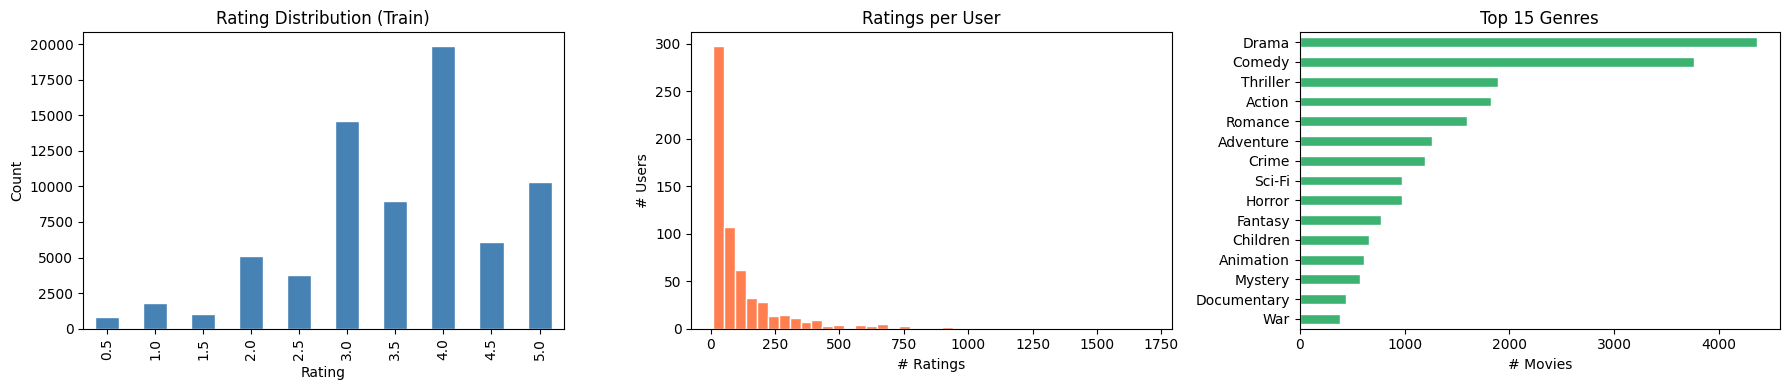

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

train["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rating Distribution (Train)")
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")

ratings_per_user = train.groupby("userId").size()
axes[1].hist(ratings_per_user, bins=40, color="coral", edgecolor="white")
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("# Ratings"); axes[1].set_ylabel("# Users")

genre_counts = Counter(g for gl in movies["genre_list"] for g in gl)
top_genres   = pd.Series(genre_counts).sort_values(ascending=True).tail(15)
top_genres.plot(kind="barh", ax=axes[2], color="mediumseagreen", edgecolor="white")
axes[2].set_title("Top 15 Genres"); axes[2].set_xlabel("# Movies")

plt.tight_layout()
plt.savefig("processed/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 - Dataset Summary

In [51]:
total_possible = movies.shape[0] * ratings["userId"].nunique()
sparsity       = 1 - (len(train) / total_possible)

summary = pd.DataFrame({
    "Metric": [
        "Total Movies", "Total Users", "Train Ratings", "Test Ratings",
        "Rating Range", "Average Rating", "Matrix Sparsity", "Unique Genres"
    ],
    "Value": [
        f"{movies.shape[0]:,}",
        f"{ratings['userId'].nunique():,}",
        f"{len(train):,}",
        f"{len(test):,}",
        f"{train['rating'].min()} – {train['rating'].max()}",
        f"{train['rating'].mean():.2f}",
        f"{sparsity:.2%}",
        str(len(set(g for gl in movies['genre_list'] for g in gl)))
    ]
})
display(summary.style.hide(axis="index"))

Metric,Value
Total Movies,"9,708"
Total Users,610
Train Ratings,"72,429"
Test Ratings,"17,838"
Rating Range,0.5 – 5.0
Average Rating,3.55
Matrix Sparsity,98.78%
Unique Genres,19


## 11 - Save Processed Files (CLEAN ONES)

In [52]:
movies.to_csv("processed/movies_clean.csv",  index=False)
train.to_csv("processed/ratings_train.csv",  index=False)
test.to_csv("processed/ratings_test.csv",    index=False)


## Step 2 — Content-Based Recommendation System (TF-IDF + Cosine Similarity)

## 1 - Prepare genres as text

In [53]:
# Convert genre list into a single string (TF-IDF needs text)
movies["genres_str"] = movies["genre_list"].apply(lambda x: " ".join(x))

movies[["title","genres","genres_str"]].head()

,title,genres,genres_str
0,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy
1,Jumanji,Adventure|Children|Fantasy,Adventure Children Fantasy
2,Grumpier Old Men,Comedy|Romance,Comedy Romance
3,Waiting to Exhale,Comedy|Drama|Romance,Comedy Drama Romance
4,Father of the Bride Part II,Comedy,Comedy


## 2 - TF-IDF Vectorization

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(movies["genres_str"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9708, 21)


## 3 - Compute Cosine Similarity

In [55]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape

(9708, 9708)

## 4 - Create a movie title index mapping

In [56]:
# Map movie titles → index positions
indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

indices.head()

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
dtype: int64

## 5 - Create the recommendation function

In [64]:
def recommend_similar_movies(title, top_n=10):
    
    matches = movies[movies["title"].str.lower() == title.lower()]
    
    if len(matches) == 0:
        return "Movie not found. Try using the search_movie() helper."
    
    if len(matches) > 1:
        return matches[["title"]]
    
    idx = matches.index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return movies["title"].iloc[movie_indices]

## 6 - Test the recommender

In [65]:
movies["title"].sample(20, random_state=42).tolist()

['Wrong Turn',
 'Jewel of the Nile, The',
 'Major Dundee',
 'Vigilante Diaries',
 'We Own the Night',
 "Hogfather (Terry Pratchett's Hogfather)",
 'Brake',
 'Versus',
 'Educating Rita',
 'Fat Girl (À ma soeur!)',
 'Amazing Panda Adventure, The',
 'Other Woman, The',
 "Trick 'r Treat",
 'Heartbreakers',
 'Easy A',
 'Ip Man 3',
 'Land That Time Forgot, The',
 'All of Me',
 'Jurassic World: Fallen Kingdom',
 'Hellbound: Hellraiser II']

In [66]:
# search for movies by keyword
def search_movie(keyword):
    return movies[movies["title"].str.contains(keyword, case=False)][["title"]].head(20)

search_movie("toy")
search_movie("star")
search_movie("love")
search_movie("batman")

,title
126,Batman Forever
509,Batman
1060,Batman Returns
1174,Batman & Robin
2418,Batman: Mask of the Phantasm
5463,Batman
5620,"Batman/Superman Movie, The"
5631,Batman Beyond: Return of the Joker
5917,Batman Begins
6815,Batman: Gotham Knight


In [67]:
recommend_similar_movies("Batman Begins")

6710                                  Dark Knight, The
8387                                    Need for Speed
6852                                         Eagle Eye
8103                           Good Day to Die Hard, A
8166    Fast & Furious 6 (Fast and the Furious 6, The)
7768                            Dark Knight Rises, The
7599           Fast Five (Fast and the Furious 5, The)
8233                                    Man of Tai Chi
8149                Grandmaster, The (Yi dai zong shi)
7031    Night at the Museum: Battle of the Smithsonian
Name: title, dtype: str

In [71]:
# recommend_similar_movies("Star Wars")
recommend_similar_movies("Fargo")

520                                              Fargo
791                                            Freeway
2453    Man Bites Dog (C'est arrivé près de chez vous)
3155                               Beautiful Creatures
4169                   Confessions of a Dangerous Mind
4523                                     Party Monster
6676                                         In Bruges
7129                                   Informant!, The
7293                                   Leaves of Grass
20                                          Get Shorty
Name: title, dtype: str